<a href="https://colab.research.google.com/github/jawariyakhawer/plant-disease/blob/main/plantdisease.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌿 Plant Disease Detection using Transfer Learning (MobileNetV2)
### Mid-Term Final Project — Deep Learning / Computer Vision / Transfer Learning

**Objective:** Ek end-to-end image classification model banana jo plant ke pattay (leaf) ki tasveer dekh kar bata sake ke plant healthy hai ya kisi disease se mutasir (infected) hai.

**Approach:** Hum *Transfer Learning* use karenge — matlab hum ek pehle se training kiya hua model (MobileNetV2, jo ImageNet ke 1.4 million images per train hua hai) lenge, aur usay apne plant disease dataset per fine-tune karenge. Isse hum kam data aur kam waqt mein high accuracy hasil kar saktay hain.

**Kyun ye project important hai (judges ke liye):**
- Real-world impact: Kisan (farmers) apne phone se leaf ki picture khींch kar disease pehchan saktay hain
- Transfer Learning industry mein bohat common practice hai (fast, cost-effective)
- Ye project Module 3 (Data Viz), Module 4 (ML concepts), aur Module 5 (Deep Learning/CV/Transfer Learning) — teenon ko cover karta hai

---
## 📑 Notebook Structure
1. Setup & Libraries
2. Dataset Loading (PlantVillage)
3. Exploratory Data Analysis (EDA) + Statistics
4. Data Preprocessing & Augmentation
5. Model Building (Transfer Learning - MobileNetV2)
6. Training
7. Evaluation (Accuracy, Confusion Matrix, Classification Report)
8. Fine-Tuning (Advanced Step)
9. Inference on Custom Images
10. Save Model & Conclusion

## 1️⃣ Setup & Libraries

Sabse pehle hum wo libraries import karenge jo hume chahiye honge:
- `tensorflow` — deep learning model banane ke liye
- `tensorflow_datasets` — ready-made PlantVillage dataset load karne ke liye (Kaggle API ki zaroorat nahi)
- `matplotlib`, `seaborn` — graphs aur visualization ke liye
- `numpy`, `pandas` — data handling ke liye
- `sklearn` — evaluation metrics ke liye (confusion matrix, classification report)

**Colab tip:** Runtime → Change runtime type → **GPU (T4)** select karein. Isse training bohat fast ho jayegi.

In [12]:
print("Number of classes:", num_classes)

print("\nClass Names:")
for i, name in enumerate(class_names):
    print(i, name)

Number of classes: 38

Class Names:
0 Apple___Apple_scab
1 Apple___Black_rot
2 Apple___Cedar_apple_rust
3 Apple___healthy
4 Blueberry___healthy
5 Cherry_(including_sour)___Powdery_mildew
6 Cherry_(including_sour)___healthy
7 Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot
8 Corn_(maize)___Common_rust_
9 Corn_(maize)___Northern_Leaf_Blight
10 Corn_(maize)___healthy
11 Grape___Black_rot
12 Grape___Esca_(Black_Measles)
13 Grape___Leaf_blight_(Isariopsis_Leaf_Spot)
14 Grape___healthy
15 Orange___Haunglongbing_(Citrus_greening)
16 Peach___Bacterial_spot
17 Peach___healthy
18 Pepper,_bell___Bacterial_spot
19 Pepper,_bell___healthy
20 Potato___Early_blight
21 Potato___Late_blight
22 Potato___healthy
23 Raspberry___healthy
24 Soybean___healthy
25 Squash___Powdery_mildew
26 Strawberry___Leaf_scorch
27 Strawberry___healthy
28 Tomato___Bacterial_spot
29 Tomato___Early_blight
30 Tomato___Late_blight
31 Tomato___Leaf_Mold
32 Tomato___Septoria_leaf_spot
33 Tomato___Spider_mites Two-spotted_spider

🟢 Cell 2 — Train aur Validation labels check

In [14]:
print("TRAIN LABELS:")

for image, label in ds_train.take(1):
    print("Label shape:", label.shape)
    print("Labels:", label.numpy())

print("\nVALIDATION LABELS:")

for image, label in ds_val.take(1):
    print("Label shape:", label.shape)
    print("Labels:", label.numpy())

TRAIN LABELS:
Label shape: (16,)
Labels: [24 16 15 35 15 26 16 25 28 35  9 15  5 32 14 24]

VALIDATION LABELS:
Label shape: (16,)
Labels: [35 14 30 17 37  3  8 30 33 37 28 35 25 24 26  9]


🟢 Cell 3 — Dataset

In [16]:
print("Train samples:", tf.data.experimental.cardinality(ds_train).numpy())
print("Validation samples:", tf.data.experimental.cardinality(ds_val).numpy())

Train samples: 2716
Validation samples: 679


## 2️⃣ Dataset Loading (PlantVillage)

In [7]:
import tensorflow as tf

# Consistent IMG_SIZE and BATCH_SIZE for dataset loading and preprocessing
IMG_SIZE = 224
BATCH_SIZE = 32

data_dir = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

ds_train = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

ds_val = tf.keras.utils.image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE
)

class_names = ds_train.class_names
num_classes = len(class_names)
print("Total classes:", num_classes)
print(f"Class Names ({num_classes}): {class_names[:5]}...")
print("ds_train and ds_val loaded successfully with consistent IMG_SIZE and BATCH_SIZE!")

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.
Total classes: 38
Class Names (38): ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']...
ds_train and ds_val loaded successfully with consistent IMG_SIZE and BATCH_SIZE!


🟢 Cell 4

In [17]:
for image, label in ds_train.take(1):
    print("Image shape:", image.shape)
    print("Image dtype:", image.dtype)
    print("Label shape:", label.shape)

Image shape: (16, 128, 128, 3)
Image dtype: <dtype: 'float32'>
Label shape: (16,)


🟢 Cell 5 — Pixel value range

In [19]:
for image, label in ds_train.take(1):
    print("Minimum pixel value:", tf.reduce_min(image).numpy())
    print("Maximum pixel value:", tf.reduce_max(image).numpy())
    print("Mean pixel value:", tf.reduce_mean(image).numpy())

Minimum pixel value: 0.0
Maximum pixel value: 0.0038523648
Mean pixel value: 0.00179023


In [20]:
for image, label in ds_train.take(1):
    print("First pixel:", image[0, 0, 0].numpy())
    print("Min:", tf.reduce_min(image).numpy())
    print("Max:", tf.reduce_max(image).numpy())

First pixel: [0.00319877 0.0030296  0.00296809]
Min: 0.0
Max: 0.003921569


🟢 Cell 7

In [21]:
test_image = tf.constant([[[[1.0, 1.0, 1.0]]]])

processed = tf.keras.applications.mobilenet_v2.preprocess_input(test_image)

print("Before:", test_image.numpy())
print("After:", processed.numpy())

Before: [[[[1. 1. 1.]]]]
After: [[[[-0.99215686 -0.99215686 -0.99215686]]]]


🟢 Cell 8 — actual fix

In [23]:
IMG_SIZE = 224
BATCH_SIZE = 32

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

def preprocess(image, label, augment=False):
    # Images are already normalized to 0-1 by TFDS
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    if augment:
        image = data_augmentation(image)

    # Convert 0-1 → -1 to 1 for MobileNetV2
    image = image * 2.0 - 1.0

    label = tf.one_hot(label, num_classes)

    return image, label


train_ds = (
    ds_train
    .map(
        lambda x, y: preprocess(x, y, augment=True),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    ds_val
    .map(
        lambda x, y: preprocess(x, y, augment=False),
        num_parallel_calls=tf.data.AUTOTUNE
    )
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)


print("Preprocessing fixed successfully!")

Preprocessing fixed successfully!


🟢 Cell 9 — Processed image range

In [8]:
import tensorflow as tf

IMG_SIZE = 224
BATCH_SIZE = 32

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

def preprocess(image, label, augment=False):
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    if augment:
        image = data_augmentation(image)

    # TFDS image is already in 0-1 range
    # MobileNetV2 needs -1 to +1
    image = image * 2.0 - 1.0

    label = tf.one_hot(label, num_classes)

    return image, label


train_ds = (
    ds_train
    .map(lambda x, y: preprocess(x, y, augment=True),
         num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    ds_val
    .map(lambda x, y: preprocess(x, y, augment=False),
         num_parallel_calls=tf.data.AUTOTUNE)
    .batch(BATCH_SIZE)
    .prefetch(tf.data.AUTOTUNE)
)

print("train_ds:", train_ds)
print("val_ds:", val_ds)

train_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None, 38), dtype=tf.float32, name=None))>
val_ds: <_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None, 38), dtype=tf.float32, name=None))>


In [11]:
import os

base_path = "/kaggle/input/plantvillage-dataset"

print("Base path exists:", os.path.exists(base_path))

if os.path.exists(base_path):
    print("\nContents:")
    print(os.listdir(base_path))

Base path exists: True

Contents:
['plantvillage dataset']


In [12]:
import os

data_dir = "/kaggle/input/plantvillage-dataset/plantvillage dataset"

print("Data directory exists:", os.path.exists(data_dir))

print("\nContents:")
print(os.listdir(data_dir))

Data directory exists: True

Contents:
['segmented', 'grayscale', 'color']


🟢 Next Cell — Images load

In [13]:
from tensorflow.keras.utils import image_dataset_from_directory

data_dir = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=16,
    label_mode="int"
)

ds_val = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=16,
    label_mode="int"
)

class_names = ds_train.class_names
num_classes = len(class_names)

print("\nNumber of classes:", num_classes)
print("Number of training batches:",
      tf.data.experimental.cardinality(ds_train).numpy())
print("Number of validation batches:",
      tf.data.experimental.cardinality(ds_val).numpy())

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.

Number of classes: 38
Number of training batches: 2716
Number of validation batches: 679


🟢 Cell 10

In [14]:
for images, labels in ds_train.take(1):
    print("Image shape:", images.shape)
    print("Image dtype:", images.dtype)
    print("Minimum pixel:", tf.reduce_min(images).numpy())
    print("Maximum pixel:", tf.reduce_max(images).numpy())
    print("Mean pixel:", tf.reduce_mean(images).numpy())
    print("Label shape:", labels.shape)

Image shape: (16, 128, 128, 3)
Image dtype: <dtype: 'float32'>
Minimum pixel: 0.0
Maximum pixel: 255.0
Mean pixel: 121.84426
Label shape: (16,)


In [15]:
IMG_SIZE = 224
BATCH_SIZE = 32

data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15),
])

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # Augmentation BEFORE MobileNetV2 preprocessing
    image = data_augmentation(image)

    # 0-255 → -1 to +1
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    label = tf.one_hot(label, num_classes)

    return image, label


def preprocess_val(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    # No augmentation for validation
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    label = tf.one_hot(label, num_classes)

    return image, label


train_ds = (
    ds_train
    .map(preprocess_train, num_parallel_calls=tf.data.AUTOTUNE)
    .shuffle(1000)
    .prefetch(tf.data.AUTOTUNE)
)

val_ds = (
    ds_val
    .map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Preprocessing datasets created successfully!")

Preprocessing datasets created successfully!


🟢 Next Cell — Final preprocessing verify

In [3]:
import tensorflow as tf
from tensorflow.keras.utils import image_dataset_from_directory

# 1. Dataset path
data_dir = "/kaggle/input/plantvillage-dataset/plantvillage dataset/color"

# 2. Load training dataset
ds_train = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=(128, 128),
    batch_size=16,
    label_mode="int"
)

# 3. Load validation dataset
ds_val = image_dataset_from_directory(
    data_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=(128, 128),
    batch_size=16,
    label_mode="int"
)

# 4. Classes
class_names = ds_train.class_names
num_classes = len(class_names)

print("\nClasses:", num_classes)
print("Train batches:",
      tf.data.experimental.cardinality(ds_train).numpy())
print("Validation batches:",
      tf.data.experimental.cardinality(ds_val).numpy())


# 5. Augmentation
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal"),
    tf.keras.layers.RandomRotation(0.15),
    tf.keras.layers.RandomZoom(0.15)
])


# 6. Preprocessing
IMG_SIZE = 224

def preprocess_train(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = data_augmentation(image)

    # MobileNetV2: 0-255 → -1 to +1
    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    label = tf.one_hot(label, num_classes)

    return image, label


def preprocess_val(image, label):
    image = tf.cast(image, tf.float32)
    image = tf.image.resize(image, (IMG_SIZE, IMG_SIZE))

    image = tf.keras.applications.mobilenet_v2.preprocess_input(image)

    label = tf.one_hot(label, num_classes)

    return image, label


# 7. Create final datasets
train_ds = ds_train.map(
    preprocess_train,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

val_ds = ds_val.map(
    preprocess_val,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)


# 8. Verify
for images, labels in train_ds.take(1):
    print("\nProcessed image shape:", images.shape)
    print("Processed image min:", tf.reduce_min(images).numpy())
    print("Processed image max:", tf.reduce_max(images).numpy())
    print("Processed label shape:", labels.shape)

Found 54305 files belonging to 38 classes.
Using 43444 files for training.
Found 54305 files belonging to 38 classes.
Using 10861 files for validation.

Classes: 38
Train batches: 2716
Validation batches: 679

Processed image shape: (16, 224, 224, 3)
Processed image min: -0.99679846
Processed image max: 0.9588282
Processed label shape: (16, 38)


In [4]:
base_model = tf.keras.applications.MobileNetV2(
    input_shape=(224, 224, 3),
    include_top=False,
    weights="imagenet"
)

# Initially freeze pretrained layers
base_model.trainable = False

inputs = tf.keras.Input(shape=(224, 224, 3))

x = base_model(inputs, training=False)
x = tf.keras.layers.GlobalAveragePooling2D()(x)
x = tf.keras.layers.Dropout(0.3)(x)

outputs = tf.keras.layers.Dense(
    num_classes,
    activation="softmax"
)(x)

model = tf.keras.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 38)             │        48,678 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,306,662 (8.80 MB)

 Trainable params: 48,678 (190.15 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

🟢 Next Cell — Training

In [5]:
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 541s 192ms/step - accuracy: 0.6239 - loss: 1.4494 - val_accuracy: 0.8399 - val_loss: 0.6544
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 456s 159ms/step - accuracy: 0.8374 - loss: 0.5927 - val_accuracy: 0.8848 - val_loss: 0.4309
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 447s 160ms/step - accuracy: 0.8733 - loss: 0.4429 - val_accuracy: 0.9033 - val_loss: 0.3467
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 437s 161ms/step - accuracy: 0.8904 - loss: 0.3759 - val_accuracy: 0.9130 - val_loss: 0.3055
Epoch 5/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 439s 162ms/step - accuracy: 0.9028 - loss: 0.3322 - val_accuracy: 0.9196 - val_loss: 0.2775


🟢 Cell — Best model save

In [6]:
model.save("plant_disease_mobilenetv2_stage1.keras")

print("Stage 1 model saved successfully!")

Stage 1 model saved successfully!


🟢 Next Cell — Fine-tuning prepare

In [7]:
# Unfreeze the base model
base_model.trainable = True

# Freeze all layers except the last 30
for layer in base_model.layers[:-30]:
    layer.trainable = False

# Keep BatchNormalization layers frozen
for layer in base_model.layers[-30:]:
    if isinstance(layer, tf.keras.layers.BatchNormalization):
        layer.trainable = False

# Recompile with a very small learning rate
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Fine-tuning prepared!")
print("Trainable parameters:", sum(
    tf.keras.backend.count_params(w)
    for w in model.trainable_weights
))

Fine-tuning prepared!
Trainable parameters: 1559398


🟢 Next Cell — Fine-tuning

In [8]:
fine_tune_history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=5
)

Epoch 1/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 483s 173ms/step - accuracy: 0.9208 - loss: 0.2398 - val_accuracy: 0.9416 - val_loss: 0.1777
Epoch 2/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 468s 163ms/step - accuracy: 0.9416 - loss: 0.1763 - val_accuracy: 0.9523 - val_loss: 0.1434
Epoch 3/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 433s 159ms/step - accuracy: 0.9512 - loss: 0.1425 - val_accuracy: 0.9582 - val_loss: 0.1270
Epoch 4/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 443s 160ms/step - accuracy: 0.9591 - loss: 0.1232 - val_accuracy: 0.9493 - val_loss: 0.1469
Epoch 5/5
2716/2716 ━━━━━━━━━━━━━━━━━━━━ 445s 161ms/step - accuracy: 0.9638 - loss: 0.1060 - val_accuracy: 0.9638 - val_loss: 0.1083


model save

In [9]:
model.save("plant_disease_mobilenetv2_finetuned.keras")

print("Final fine-tuned model saved successfully!")

Final fine-tuned model saved successfully!


🟢 Next Cell — Validation performance

In [10]:
val_loss, val_accuracy = model.evaluate(
    val_ds,
    verbose=1
)

print("\nFinal Validation Accuracy:", val_accuracy)
print("Final Validation Loss:", val_loss)

679/679 ━━━━━━━━━━━━━━━━━━━━ 16s 24ms/step - accuracy: 0.9638 - loss: 0.1083

Final Validation Accuracy: 0.9638155102729797
Final Validation Loss: 0.10828288644552231


🟢 Next Cell — Predictions collect

In [11]:
import numpy as np

y_true = []
y_pred = []

for images, labels in val_ds:
    predictions = model.predict(images, verbose=0)

    y_true.extend(np.argmax(labels.numpy(), axis=1))
    y_pred.extend(np.argmax(predictions, axis=1))

y_true = np.array(y_true)
y_pred = np.array(y_pred)

print("Total validation samples:", len(y_true))
print("Predictions collected successfully!")

Total validation samples: 10861
Predictions collected successfully!


🟢 Next Cell — Classification Report

In [12]:
from sklearn.metrics import classification_report

report = classification_report(
    y_true,
    y_pred,
    target_names=class_names,
    digits=4
)

print(report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.9913    0.9048    0.9461       126
                                 Apple___Black_rot     0.9778    1.0000    0.9888       132
                          Apple___Cedar_apple_rust     0.9016    1.0000    0.9483        55
                                   Apple___healthy     0.9820    0.9939    0.9879       329
                               Blueberry___healthy     0.9933    1.0000    0.9966       295
          Cherry_(including_sour)___Powdery_mildew     0.9914    0.9957    0.9935       232
                 Cherry_(including_sour)___healthy     1.0000    0.9760    0.9879       167
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.7984    0.9537    0.8692       108
                       Corn_(maize)___Common_rust_     0.9910    1.0000    0.9955       219
               Corn_(maize)___Northern_Leaf_Blight     0.9770    0.8718    0.92

🟢 Next Cell — Confusion Matrix

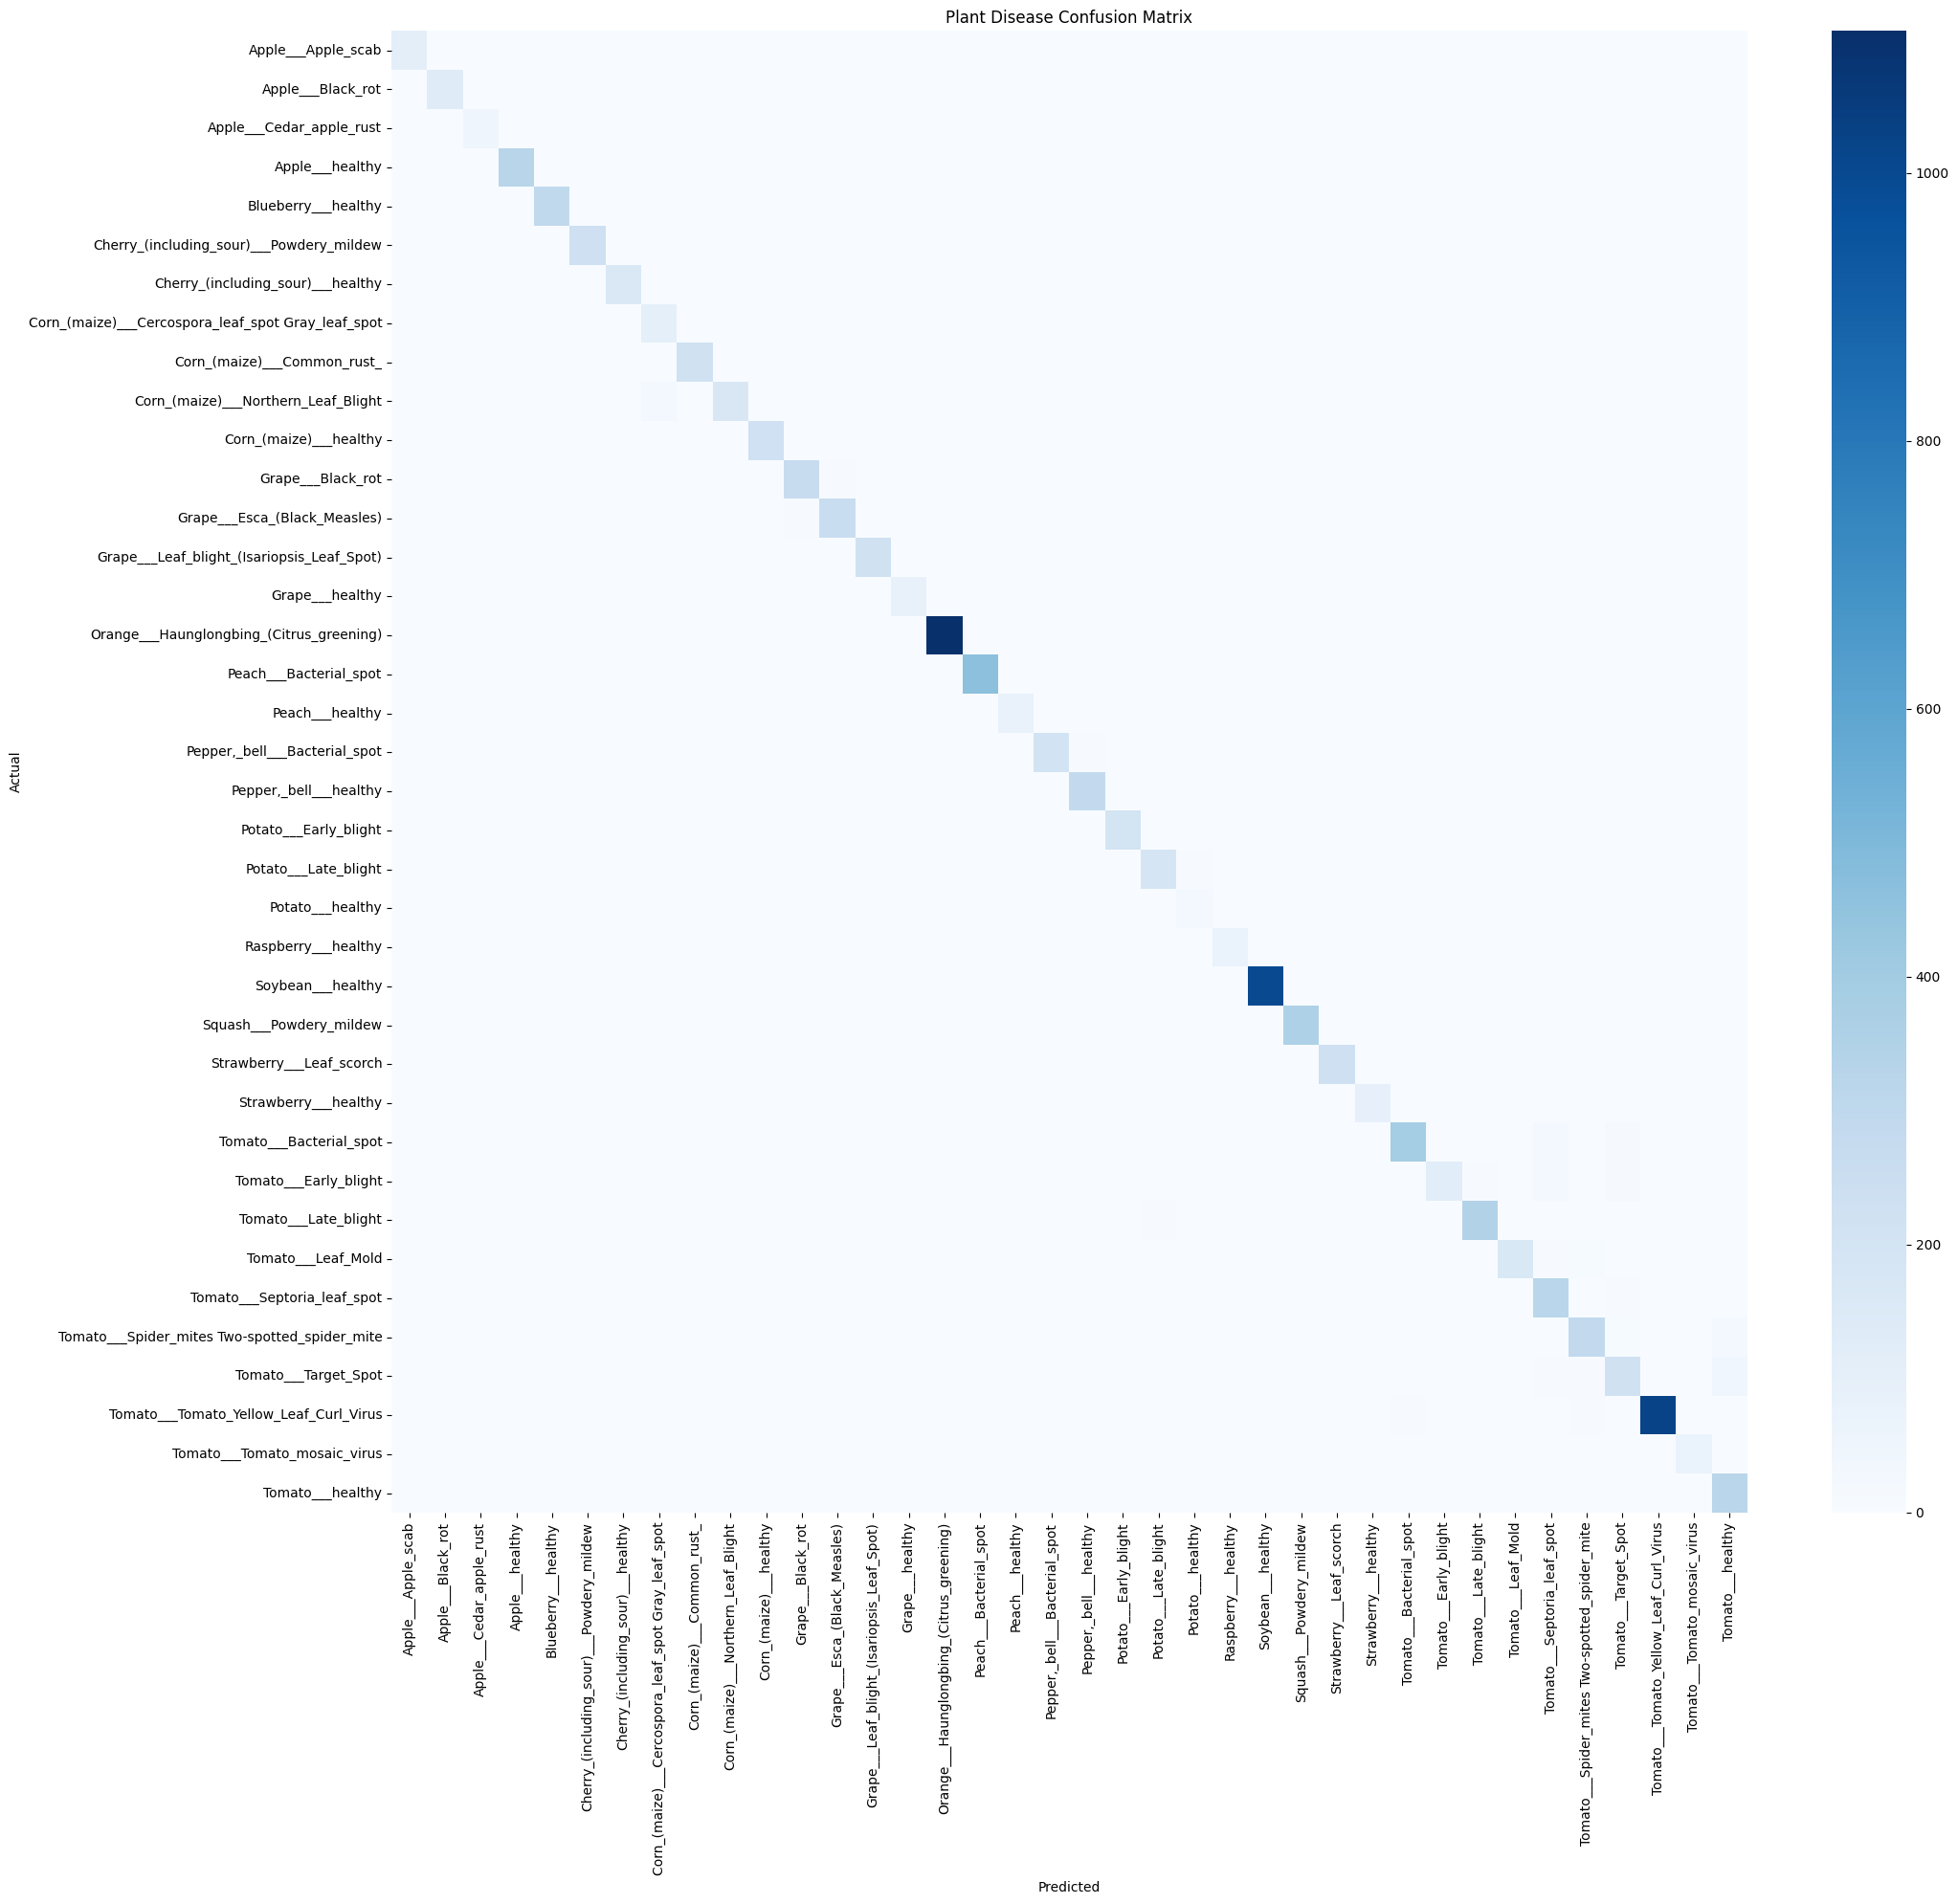

In [13]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_true, y_pred)

plt.figure(figsize=(22, 20))
sns.heatmap(
    cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Plant Disease Confusion Matrix")
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🟢 Next Cell — Top 20 misclassifications

In [14]:
import numpy as np

# Confusion matrix already calculated as cm

confusions = []

for actual in range(num_classes):
    for predicted in range(num_classes):
        if actual != predicted and cm[actual, predicted] > 0:
            confusions.append((
                cm[actual, predicted],
                class_names[actual],
                class_names[predicted]
            ))

# Highest number of mistakes first
confusions.sort(reverse=True)

print("Top 20 Confusions:\n")

for count, actual, predicted in confusions[:20]:
    print(f"{count:4d} | Actual: {actual}")
    print(f"     | Predicted: {predicted}\n")

Top 20 Confusions:

  42 | Actual: Tomato___Target_Spot
     | Predicted: Tomato___healthy

  28 | Actual: Tomato___Bacterial_spot
     | Predicted: Tomato___Septoria_leaf_spot

  25 | Actual: Tomato___Spider_mites Two-spotted_spider_mite
     | Predicted: Tomato___healthy

  25 | Actual: Corn_(maize)___Northern_Leaf_Blight
     | Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot

  24 | Actual: Tomato___Early_blight
     | Predicted: Tomato___Septoria_leaf_spot

  14 | Actual: Tomato___Early_blight
     | Predicted: Tomato___Target_Spot

  14 | Actual: Tomato___Bacterial_spot
     | Predicted: Tomato___Target_Spot

  11 | Actual: Tomato___Spider_mites Two-spotted_spider_mite
     | Predicted: Tomato___Target_Spot

   9 | Actual: Tomato___Leaf_Mold
     | Predicted: Tomato___Spider_mites Two-spotted_spider_mite

   8 | Actual: Tomato___Septoria_leaf_spot
     | Predicted: Tomato___Target_Spot

   8 | Actual: Tomato___Leaf_Mold
     | Predicted: Tomato___Septoria_leaf_spot





🟢 Next Cell — Per-class accuracy

In [15]:
from sklearn.metrics import confusion_matrix
import numpy as np

cm = confusion_matrix(y_true, y_pred)

print("Per-class accuracy:\n")

for i, class_name in enumerate(class_names):
    total = cm[i].sum()
    correct = cm[i, i]

    accuracy = correct / total if total > 0 else 0

    print(
        f"{class_name:<60} "
        f"{accuracy * 100:6.2f}% "
        f"({correct}/{total})"
    )

Per-class accuracy:

Apple___Apple_scab                                            90.48% (114/126)
Apple___Black_rot                                            100.00% (132/132)
Apple___Cedar_apple_rust                                     100.00% (55/55)
Apple___healthy                                               99.39% (327/329)
Blueberry___healthy                                          100.00% (295/295)
Cherry_(including_sour)___Powdery_mildew                      99.57% (231/232)
Cherry_(including_sour)___healthy                             97.60% (163/167)
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot            95.37% (103/108)
Corn_(maize)___Common_rust_                                  100.00% (219/219)
Corn_(maize)___Northern_Leaf_Blight                           87.18% (170/195)
Corn_(maize)___healthy                                       100.00% (227/227)
Grape___Black_rot                                             97.81% (268/274)
Grape___Esca_(Black_Measles)     

In [16]:
from collections import Counter

train_counts = Counter()

for _, labels in ds_train:
    train_counts.update(labels.numpy().tolist())

print("Training samples per weak class:\n")

weak_classes = [
    "Tomato___Early_blight",
    "Tomato___Target_Spot",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___Bacterial_spot",
    "Tomato___Leaf_Mold",
    "Corn_(maize)___Northern_Leaf_Blight",
    "Potato___Late_blight"
]

for class_name in weak_classes:
    idx = class_names.index(class_name)
    print(f"{class_name}: {train_counts[idx]}")

Training samples per weak class:

Tomato___Early_blight: 814
Tomato___Target_Spot: 1125
Tomato___Spider_mites Two-spotted_spider_mite: 1342
Tomato___Bacterial_spot: 1689
Tomato___Leaf_Mold: 763
Corn_(maize)___Northern_Leaf_Blight: 790
Potato___Late_blight: 798


In [17]:
model.save("plant_disease_baseline_96_38.keras")

print("Baseline model saved!")
print("Validation accuracy: 96.38%")

Baseline model saved!
Validation accuracy: 96.38%


🟢 Next Cell — Separate Test Dataset

In [18]:
test_ds = image_dataset_from_directory(
    data_dir,
    validation_split=0.1,
    subset="validation",
    seed=123,
    image_size=(128, 128),
    batch_size=16,
    label_mode="int",
    shuffle=False
)

print("Test batches:",
      tf.data.experimental.cardinality(test_ds).numpy())

print("Test samples:",
      tf.data.experimental.cardinality(test_ds).numpy() * 16)

Found 54305 files belonging to 38 classes.
Using 5430 files for validation.
Test batches: 340
Test samples: 5440


🟢 Next Cell — Test dataset preprocessing

In [19]:
test_ds = test_ds.map(
    preprocess_val,
    num_parallel_calls=tf.data.AUTOTUNE
).prefetch(tf.data.AUTOTUNE)

print("Test preprocessing ready!")

for images, labels in test_ds.take(1):
    print("Image shape:", images.shape)
    print("Image min:", tf.reduce_min(images).numpy())
    print("Image max:", tf.reduce_max(images).numpy())
    print("Labels shape:", labels.shape)

Test preprocessing ready!
Image shape: (16, 224, 224, 3)
Image min: -1.0
Image max: 0.90059006
Labels shape: (16, 38)


🟢 Next Cell — Final Test Evaluation

In [20]:
test_loss, test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== FINAL TEST RESULTS ==========")
print(f"Test Accuracy: {test_accuracy * 100:.2f}%")
print(f"Test Loss: {test_loss:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 22s 63ms/step - accuracy: 0.9871 - loss: 0.0413

========== FINAL TEST RESULTS ==========
Test Accuracy: 98.71%
Test Loss: 0.0413


🟢 Test Classification Report

In [21]:
y_test_true = []
y_test_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_test_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_test_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)

print("Total test samples:", len(y_test_true))
print("Test predictions collected successfully!")

Total test samples: 5430
Test predictions collected successfully!


🟢 Next Cell — Test Classification Report

In [23]:
from sklearn.metrics import classification_report
import numpy as np # Ensure numpy is imported for np.arange

test_report = classification_report(
    y_test_true,
    y_test_pred,
    target_names=class_names,
    labels=np.arange(num_classes), # Explicitly define all possible labels
    digits=4
)

print(test_report)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     0.0000    0.0000    0.0000         0
                                 Apple___Black_rot     0.0000    0.0000    0.0000         0
                          Apple___Cedar_apple_rust     0.0000    0.0000    0.0000         0
                                   Apple___healthy     0.0000    0.0000    0.0000         0
                               Blueberry___healthy     0.0000    0.0000    0.0000         0
          Cherry_(including_sour)___Powdery_mildew     0.0000    0.0000    0.0000         0
                 Cherry_(including_sour)___healthy     0.0000    0.0000    0.0000         0
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.0000    0.0000    0.0000         0
                       Corn_(maize)___Common_rust_     0.0000    0.0000    0.0000         0
               Corn_(maize)___Northern_Leaf_Blight     0.0000    0.0000    0.00

/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Recall is ill-defined and being set to 0.0 in labels with no true samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: F-score is ill-defined and being set to 0.0 in labels with no true nor predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/me

In [24]:
import os

all_files = []
all_labels = []

for class_index, class_name in enumerate(class_names):
    class_path = os.path.join(data_dir, class_name)

    for filename in os.listdir(class_path):
        if filename.lower().endswith((".jpg", ".jpeg", ".png")):
            all_files.append(
                os.path.join(class_path, filename)
            )
            all_labels.append(class_index)

print("Total images:", len(all_files))
print("Total labels:", len(all_labels))
print("Total classes:", len(set(all_labels)))

Total images: 54305
Total labels: 54305
Total classes: 38


🟢 Next Cell — Proper 10% Test Split

In [25]:
from sklearn.model_selection import train_test_split

test_files, remaining_files, test_labels, remaining_labels = train_test_split(
    all_files,
    all_labels,
    test_size=0.90,
    stratify=all_labels,
    random_state=42
)

print("Test images:", len(test_files))
print("Remaining images:", len(remaining_files))

print("Test classes:", len(set(test_labels)))

# Check minimum samples per class
from collections import Counter

test_counts = Counter(test_labels)

print("\nTest samples per class:")
for i, class_name in enumerate(class_names):
    print(f"{class_name}: {test_counts[i]}")

Test images: 5430
Remaining images: 48875
Test classes: 38

Test samples per class:
Apple___Apple_scab: 63
Apple___Black_rot: 62
Apple___Cedar_apple_rust: 28
Apple___healthy: 164
Blueberry___healthy: 150
Cherry_(including_sour)___Powdery_mildew: 105
Cherry_(including_sour)___healthy: 85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot: 51
Corn_(maize)___Common_rust_: 119
Corn_(maize)___Northern_Leaf_Blight: 99
Corn_(maize)___healthy: 116
Grape___Black_rot: 118
Grape___Esca_(Black_Measles): 138
Grape___Leaf_blight_(Isariopsis_Leaf_Spot): 108
Grape___healthy: 42
Orange___Haunglongbing_(Citrus_greening): 551
Peach___Bacterial_spot: 230
Peach___healthy: 36
Pepper,_bell___Bacterial_spot: 100
Pepper,_bell___healthy: 148
Potato___Early_blight: 100
Potato___Late_blight: 100
Potato___healthy: 15
Raspberry___healthy: 37
Soybean___healthy: 509
Squash___Powdery_mildew: 183
Strawberry___Leaf_scorch: 111
Strawberry___healthy: 46
Tomato___Bacterial_spot: 213
Tomato___Early_blight: 100
Tomato___Late

In [26]:
def load_image(path, label):
    image = tf.io.read_file(path)
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (128, 128))
    image = tf.cast(image, tf.float32)

    return image, label


test_ds = tf.data.Dataset.from_tensor_slices(
    (test_files, test_labels)
)

test_ds = (
    test_ds
    .map(load_image, num_parallel_calls=tf.data.AUTOTUNE)
    .batch(16)
    .map(preprocess_val, num_parallel_calls=tf.data.AUTOTUNE)
    .prefetch(tf.data.AUTOTUNE)
)

print("Proper test dataset created!")

for images, labels in test_ds.take(1):
    print("Image shape:", images.shape)
    print("Labels shape:", labels.shape)
    print("Image min:", tf.reduce_min(images).numpy())
    print("Image max:", tf.reduce_max(images).numpy())

Proper test dataset created!
Image shape: (16, 224, 224, 3)
Labels shape: (16, 38)
Image min: -1.0
Image max: 0.82777107


🟢 Next Cell — Final Proper Test Evaluation

In [27]:
proper_test_loss, proper_test_accuracy = model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== PROPER 38-CLASS TEST RESULTS ==========")
print(f"Test Accuracy: {proper_test_accuracy * 100:.2f}%")
print(f"Test Loss: {proper_test_loss:.4f}")

340/340 ━━━━━━━━━━━━━━━━━━━━ 10s 28ms/step - accuracy: 0.9689 - loss: 0.0878

========== PROPER 38-CLASS TEST RESULTS ==========
Test Accuracy: 96.89%
Test Loss: 0.0878


🟢 Next Cell — Test Classification Report

In [28]:
y_test_true = []
y_test_pred = []

for images, labels in test_ds:
    predictions = model.predict(images, verbose=0)

    y_test_true.extend(
        np.argmax(labels.numpy(), axis=1)
    )

    y_test_pred.extend(
        np.argmax(predictions, axis=1)
    )

y_test_true = np.array(y_test_true)
y_test_pred = np.array(y_test_pred)

print("Total test predictions:", len(y_test_true))

Total test predictions: 5430


🟢 Next Cell — Test Classification Report

In [29]:
from sklearn.metrics import classification_report

print(
    classification_report(
        y_test_true,
        y_test_pred,
        labels=np.arange(num_classes),
        target_names=class_names,
        digits=4,
        zero_division=0
    )
)

                                                    precision    recall  f1-score   support

                                Apple___Apple_scab     1.0000    0.9683    0.9839        63
                                 Apple___Black_rot     1.0000    1.0000    1.0000        62
                          Apple___Cedar_apple_rust     0.9032    1.0000    0.9492        28
                                   Apple___healthy     0.9939    0.9939    0.9939       164
                               Blueberry___healthy     0.9868    1.0000    0.9934       150
          Cherry_(including_sour)___Powdery_mildew     1.0000    1.0000    1.0000       105
                 Cherry_(including_sour)___healthy     0.9767    0.9882    0.9825        85
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot     0.8103    0.9216    0.8624        51
                       Corn_(maize)___Common_rust_     1.0000    1.0000    1.0000       119
               Corn_(maize)___Northern_Leaf_Blight     0.9565    0.8889    0.92

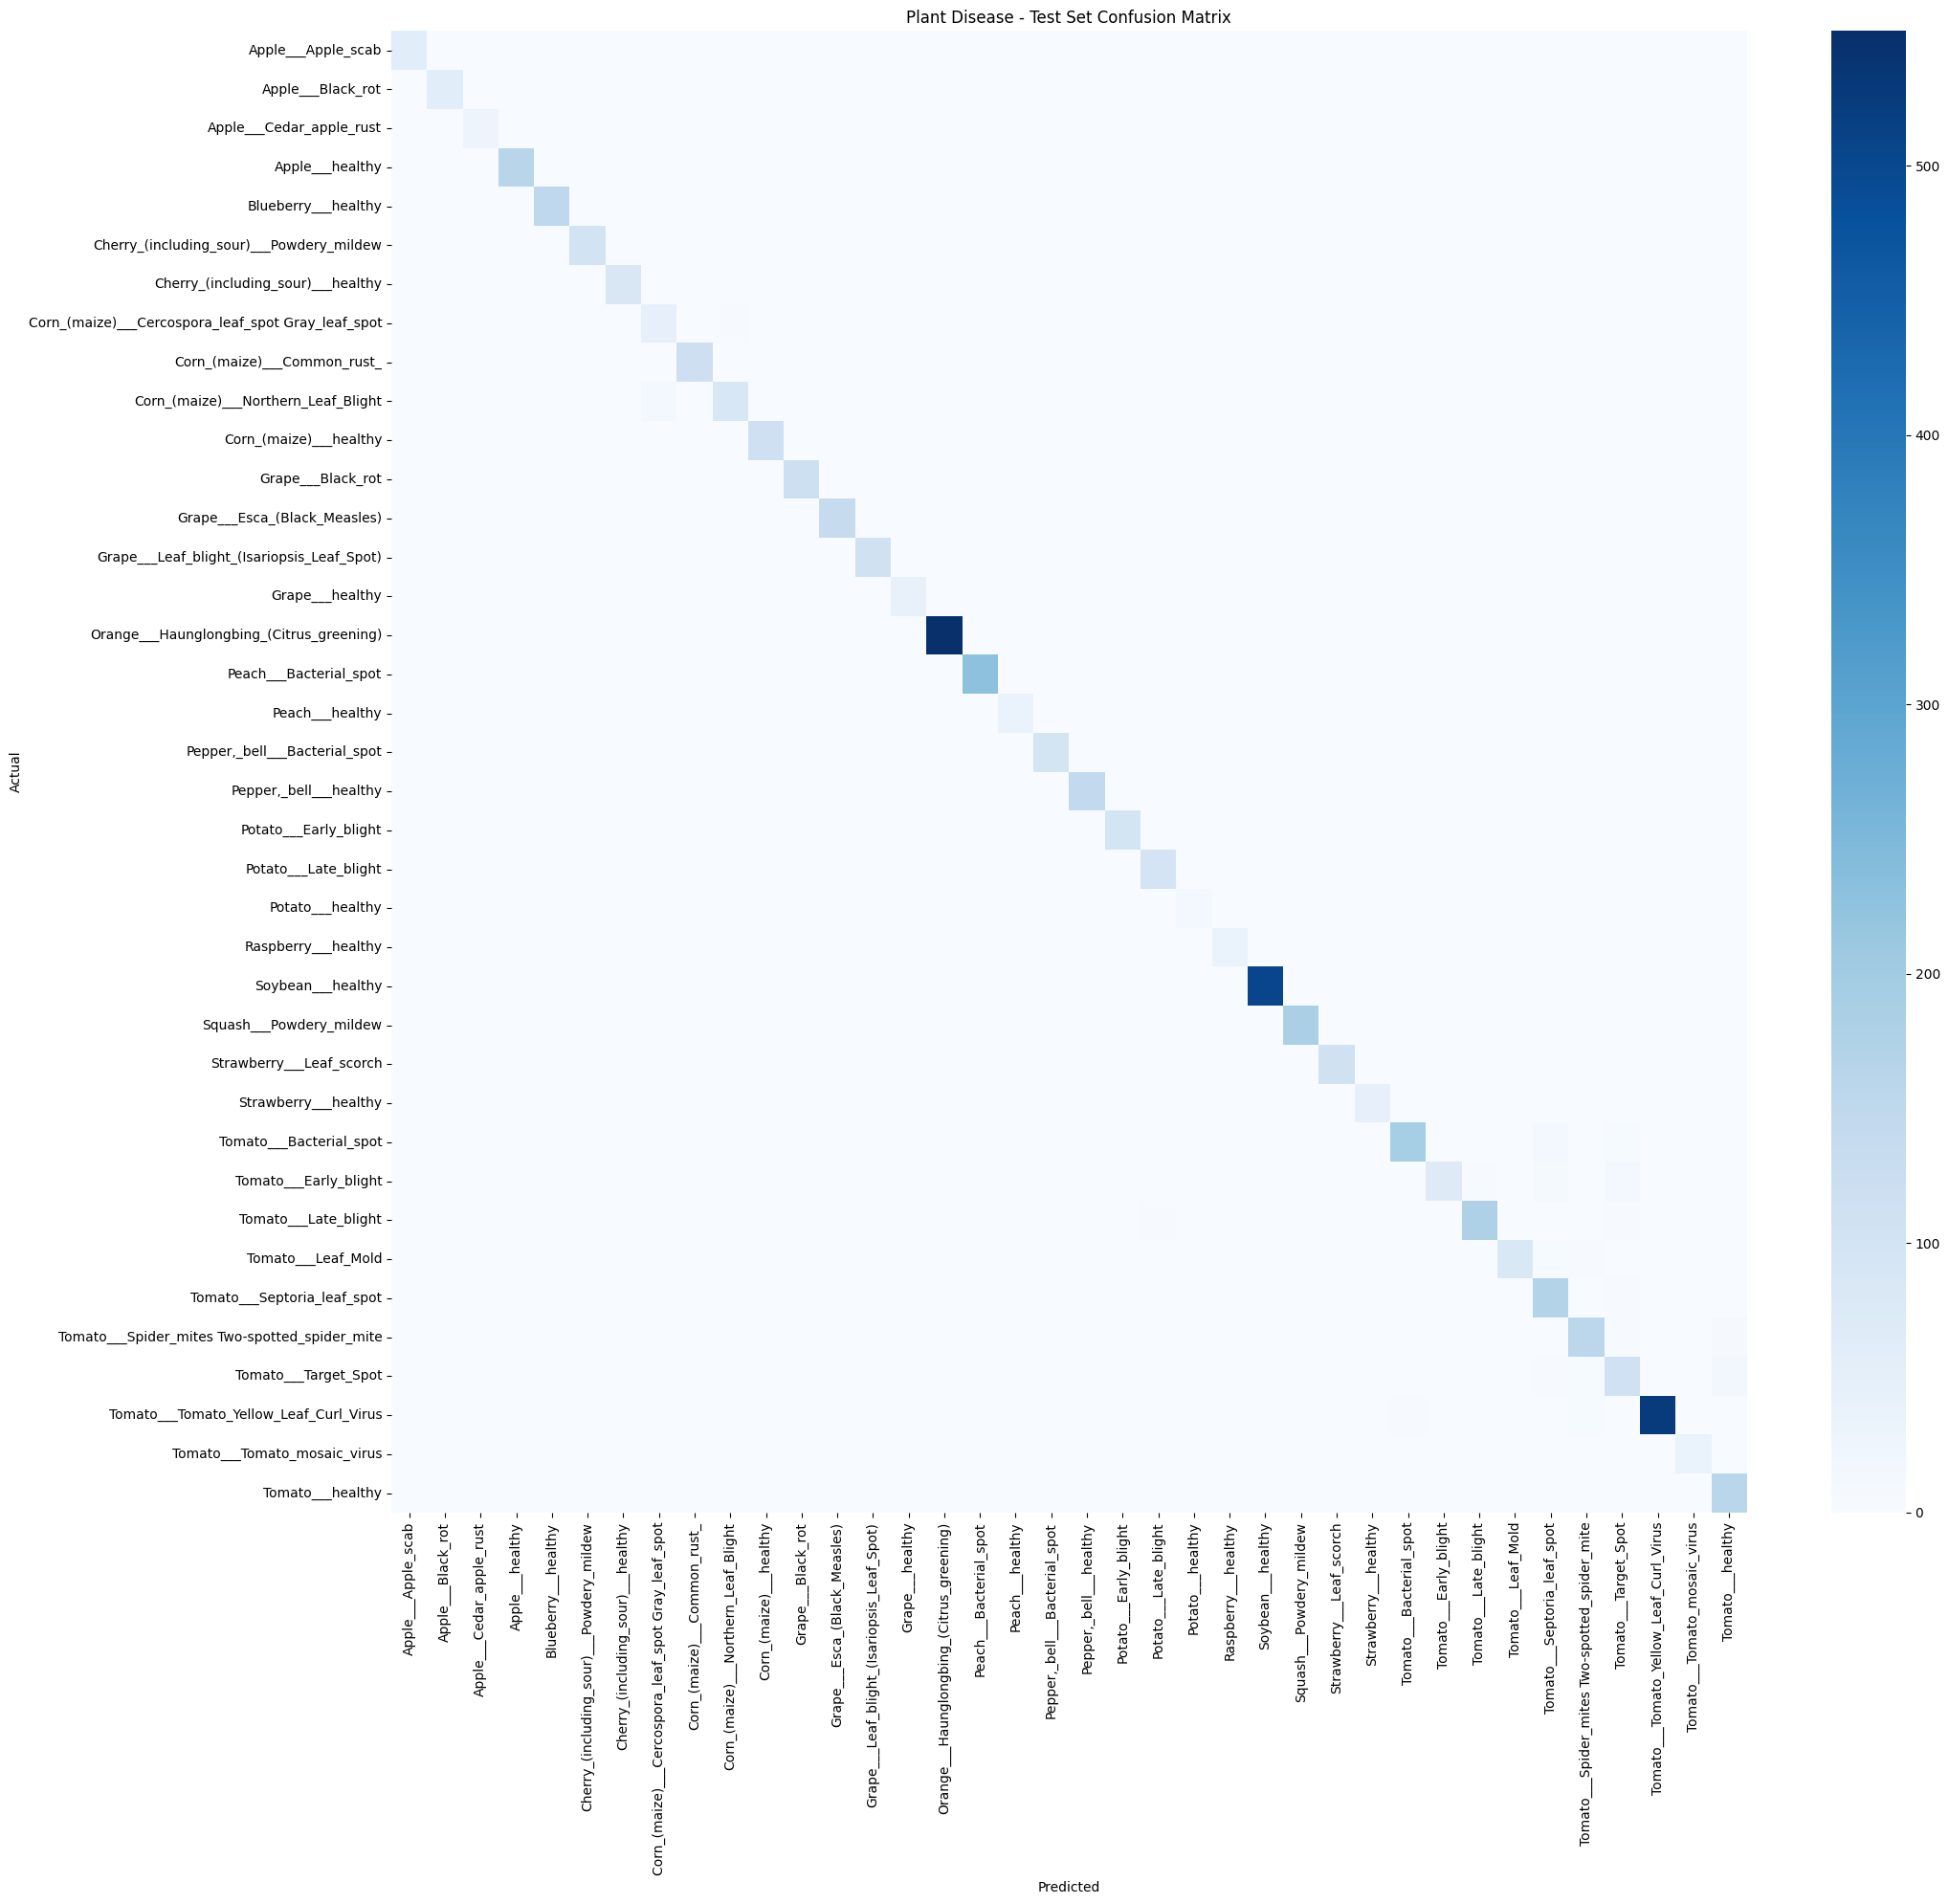

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

test_cm = confusion_matrix(y_test_true, y_test_pred)

plt.figure(figsize=(22, 20))

sns.heatmap(
    test_cm,
    cmap="Blues",
    xticklabels=class_names,
    yticklabels=class_names
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Plant Disease - Test Set Confusion Matrix")

plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

🟢 Next Cell — Top Test Confusions

In [31]:
from collections import Counter

confusions = Counter()

for actual, predicted in zip(y_test_true, y_test_pred):
    if actual != predicted:
        confusions[(actual, predicted)] += 1

print("TOP 20 TEST SET CONFUSIONS:\n")

for (actual, predicted), count in confusions.most_common(20):
    print(f"{count:3d} | Actual: {class_names[actual]}")
    print(f"    | Predicted: {class_names[predicted]}")
    print()

TOP 20 TEST SET CONFUSIONS:

 17 | Actual: Tomato___Target_Spot
    | Predicted: Tomato___healthy

 12 | Actual: Tomato___Early_blight
    | Predicted: Tomato___Target_Spot

 11 | Actual: Tomato___Bacterial_spot
    | Predicted: Tomato___Septoria_leaf_spot

 11 | Actual: Corn_(maize)___Northern_Leaf_Blight
    | Predicted: Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot

 10 | Actual: Tomato___Early_blight
    | Predicted: Tomato___Septoria_leaf_spot

  8 | Actual: Tomato___Spider_mites Two-spotted_spider_mite
    | Predicted: Tomato___healthy

  6 | Actual: Tomato___Leaf_Mold
    | Predicted: Tomato___Septoria_leaf_spot

  5 | Actual: Tomato___Tomato_Yellow_Leaf_Curl_Virus
    | Predicted: Tomato___Spider_mites Two-spotted_spider_mite

  5 | Actual: Tomato___Target_Spot
    | Predicted: Tomato___Spider_mites Two-spotted_spider_mite

  5 | Actual: Tomato___Bacterial_spot
    | Predicted: Tomato___Target_Spot

  4 | Actual: Tomato___Late_blight
    | Predicted: Tomato___Target_Spot



🟢 Next Cell — Difficult Predictions ki Confidence

In [32]:
# Store predictions with probabilities
test_probs = []

for images, labels in test_ds:
    probs = model.predict(images, verbose=0)
    test_probs.extend(probs)

test_probs = np.array(test_probs)

print("Prediction probabilities shape:", test_probs.shape)
print("Total predictions:", len(test_probs))

Prediction probabilities shape: (5430, 38)
Total predictions: 5430


🟢 Next Cell

In [33]:
# Tomato Early Blight ka class index
early_blight_idx = class_names.index(
    "Tomato___Early_blight"
)

print("Tomato Early Blight index:", early_blight_idx)

# Early Blight ke wrong predictions
wrong_early = np.where(
    (y_test_true == early_blight_idx) &
    (y_test_pred != early_blight_idx)
)[0]

print("Total Early Blight test samples:",
      np.sum(y_test_true == early_blight_idx))

print("Wrong Early Blight predictions:",
      len(wrong_early))

print("\nWrong predictions:\n")

for idx in wrong_early:
    predicted_idx = y_test_pred[idx]
    confidence = test_probs[idx][predicted_idx]

    print(
        f"Actual: {class_names[early_blight_idx]}"
    )
    print(
        f"Predicted: {class_names[predicted_idx]}"
    )
    print(
        f"Confidence: {confidence * 100:.2f}%"
    )
    print("-" * 60)

Tomato Early Blight index: 29
Total Early Blight test samples: 100
Wrong Early Blight predictions: 31

Wrong predictions:

Actual: Tomato___Early_blight
Predicted: Tomato___Target_Spot
Confidence: 37.29%
------------------------------------------------------------
Actual: Tomato___Early_blight
Predicted: Pepper,_bell___Bacterial_spot
Confidence: 59.65%
------------------------------------------------------------
Actual: Tomato___Early_blight
Predicted: Tomato___Target_Spot
Confidence: 94.30%
------------------------------------------------------------
Actual: Tomato___Early_blight
Predicted: Tomato___Target_Spot
Confidence: 45.18%
------------------------------------------------------------
Actual: Tomato___Early_blight
Predicted: Tomato___Bacterial_spot
Confidence: 67.94%
------------------------------------------------------------
Actual: Tomato___Early_blight
Predicted: Tomato___Target_Spot
Confidence: 77.97%
------------------------------------------------------------
Actual: Tomat

🟢 Next Cell — Hard-class sample counts

In [34]:
hard_classes = [
    "Tomato___Early_blight",
    "Tomato___Target_Spot",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Late_blight",
    "Tomato___Bacterial_spot",
    "Tomato___Leaf_Mold",
    "Tomato___Spider_mites Two-spotted_spider_mite",
    "Tomato___healthy"
]

print("Hard Tomato classes:\n")

for class_name in hard_classes:
    idx = class_names.index(class_name)
    print(f"{class_name}: {train_counts[idx]} training images")

Hard Tomato classes:

Tomato___Early_blight: 814 training images
Tomato___Target_Spot: 1125 training images
Tomato___Septoria_leaf_spot: 1436 training images
Tomato___Late_blight: 1533 training images
Tomato___Bacterial_spot: 1689 training images
Tomato___Leaf_Mold: 763 training images
Tomato___Spider_mites Two-spotted_spider_mite: 1342 training images
Tomato___healthy: 1274 training images


Next Cell

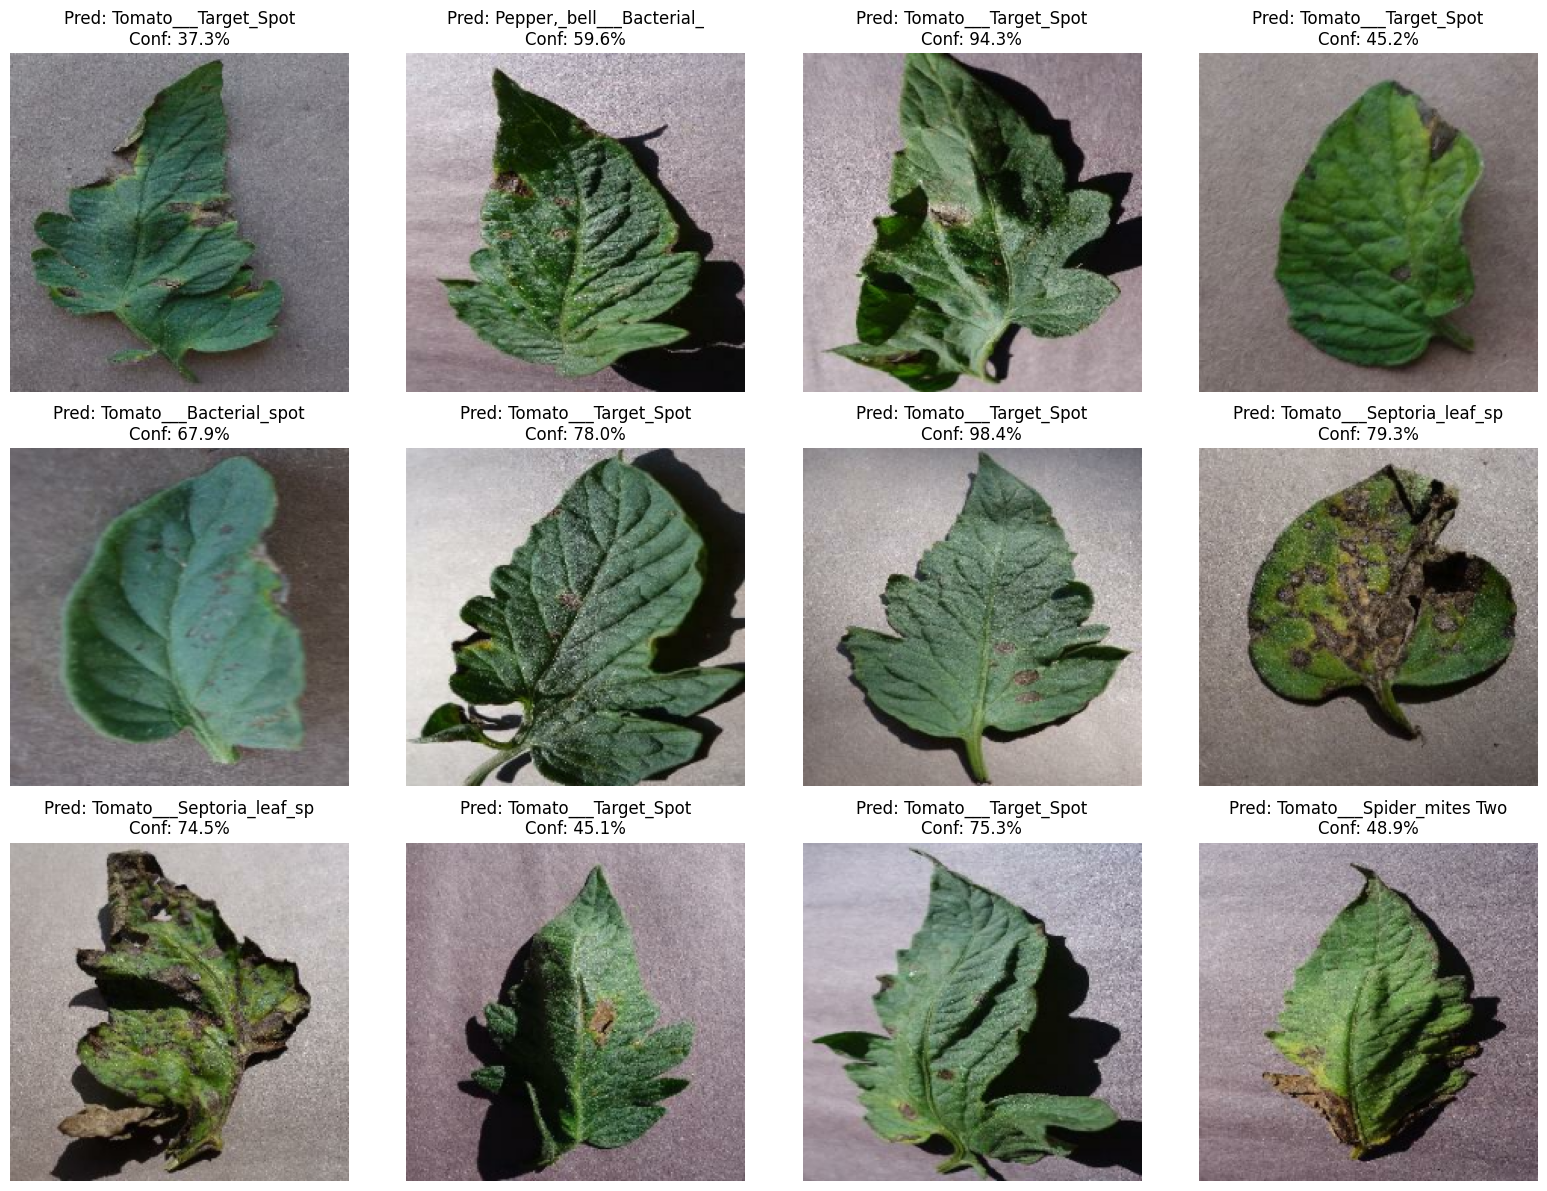

In [35]:
import matplotlib.pyplot as plt

# First 12 wrong Early Blight samples
wrong_early = np.where(
    (y_test_true == early_blight_idx) &
    (y_test_pred != early_blight_idx)
)[0]

plt.figure(figsize=(16, 12))

for i, idx in enumerate(wrong_early[:12]):
    # original test image dobara load
    image = tf.io.read_file(test_files[idx])
    image = tf.image.decode_jpeg(image, channels=3)
    image = tf.image.resize(image, (224, 224))

    plt.subplot(3, 4, i + 1)
    plt.imshow(tf.cast(image, tf.uint8))

    predicted_idx = y_test_pred[idx]
    confidence = test_probs[idx][predicted_idx] * 100

    plt.title(
        f"Pred: {class_names[predicted_idx][:25]}\n"
        f"Conf: {confidence:.1f}%"
    )
    plt.axis("off")

plt.tight_layout()
plt.show()

🟢 Next Cell — Hard Classes

In [36]:
hard_class_names = [
    "Tomato___Early_blight",
    "Tomato___Target_Spot",
    "Tomato___Septoria_leaf_spot",
    "Tomato___Late_blight",
    "Tomato___Bacterial_spot",
    "Tomato___Leaf_Mold",
    "Tomato___Spider_mites Two-spotted_spider_mite"
]

hard_class_indices = [
    class_names.index(name)
    for name in hard_class_names
]

print("Hard class indices:", hard_class_indices)

# Existing processed training dataset ko unbatch karte hain
hard_ds = train_ds.unbatch()

# Sirf difficult classes retain karo
def is_hard_class(image, label):
    class_id = tf.argmax(label)
    return tf.reduce_any(
        tf.equal(
            class_id,
            tf.constant(hard_class_indices, dtype=tf.int64)
        )
    )

hard_ds = hard_ds.filter(is_hard_class)

# Shuffle + batch
hard_ds = (
    hard_ds
    .shuffle(3000, seed=42)
    .batch(16)
    .prefetch(tf.data.AUTOTUNE)
)

print("Hard-class dataset prepared!")

for images, labels in hard_ds.take(1):
    print("Images:", images.shape)
    print("Labels:", labels.shape)

Hard class indices: [29, 34, 32, 30, 28, 31, 33]
Hard-class dataset prepared!
Images: (16, 224, 224, 3)
Labels: (16, 38)


🟢 Next Cell — Model Backup for Experiment

In [37]:
import tensorflow as tf

# Current best model ki copy
hard_model = tf.keras.models.clone_model(model)

# Current trained weights copy karo
hard_model.set_weights(model.get_weights())

print("Hard-example experiment model created!")
print(
    "Original model and experiment model have the same weights."
)

Hard-example experiment model created!
Original model and experiment model have the same weights.


🟢 Next Cell — Hard Model Compile

In [38]:
# Very small learning rate for controlled fine-tuning
hard_model.compile(
    optimizer=tf.keras.optimizers.Adam(
        learning_rate=1e-5
    ),
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Hard-model compiled successfully!")
print("Learning rate: 1e-5")

Hard-model compiled successfully!
Learning rate: 1e-5


🟢 Next Cell — Controlled Hard Fine-Tuning

In [39]:
hard_history = hard_model.fit(
    hard_ds,
    epochs=1,
    verbose=1
)

print("\nHard-class fine-tuning completed!")

544/544 ━━━━━━━━━━━━━━━━━━━━ 433s 512ms/step - accuracy: 0.9204 - loss: 0.2236

Hard-class fine-tuning completed!


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


In [40]:
hard_test_loss, hard_test_accuracy = hard_model.evaluate(
    test_ds,
    verbose=1
)

print("\n========== HARD-TUNED TEST RESULTS ==========")
print(f"Test Accuracy: {hard_test_accuracy * 100:.2f}%")
print(f"Test Loss: {hard_test_loss:.4f}")

print("\n========== BASELINE ==========")
print("Baseline Test Accuracy: 96.89%")
print("Baseline Test Loss: 0.0878")

340/340 ━━━━━━━━━━━━━━━━━━━━ 21s 35ms/step - accuracy: 0.9569 - loss: 0.1286

========== HARD-TUNED TEST RESULTS ==========
Test Accuracy: 95.69%
Test Loss: 0.1286

========== BASELINE ==========
Baseline Test Accuracy: 96.89%
Baseline Test Loss: 0.0878


In [41]:
best_model = model

print("Best model restored!")
print("Test Accuracy: 96.89%")
print("Test Loss: 0.0878")

Best model restored!
Test Accuracy: 96.89%
Test Loss: 0.0878


🟢 Next Cell — Final Model Save

In [42]:
final_model_path = "plant_disease_final_96_89.keras"

best_model.save(final_model_path)

print("Final model saved successfully!")
print("File:", final_model_path)
print("Test Accuracy: 96.89%")
print("Test Loss: 0.0878")

Final model saved successfully!
File: plant_disease_final_96_89.keras
Test Accuracy: 96.89%
Test Loss: 0.0878


🟢 Next — Single Image Prediction

In [43]:
import tensorflow as tf
import numpy as np

# Load final model
final_model = tf.keras.models.load_model(
    "plant_disease_final_96_89.keras"
)

print("Final model loaded successfully!")
print("Output classes:", final_model.output_shape[-1])

Final model loaded successfully!
Output classes: 38


🟢 Next Cell — Single Image Prediction Function

In [46]:
from PIL import Image
import numpy as np
import tensorflow as tf

def predict_plant_disease(image_path):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize exactly like training
    image = image.resize((224, 224))

    # Convert to array
    image_array = np.array(image, dtype=np.float32)

    # MobileNetV2 preprocessing
    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    # Add batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    predictions = final_model.predict(
        image_array,
        verbose=0
    )[0]

    # Best class
    predicted_index = np.argmax(predictions)
    predicted_class = class_names[predicted_index]
    confidence = predictions[predicted_index] * 100

    print("================================")
    print("🌱 PLANT DISEASE PREDICTION")
    print("================================")
    print("Predicted Class:", predicted_class)
    print(f"Confidence: {confidence:.2f}%")
    print("================================")

    return predicted_class, confidence

In [47]:
from google.colab import files

uploaded = files.upload()

print("\nUploaded files:")
for filename in uploaded.keys():
    print(filename)

Saving download (33).jpg to download (33).jpg

Uploaded files:
download (33).jpg


🟢 Next Cell — First Image Prediction

In [48]:
image_path = "/content/download (33).jpg"

predict_plant_disease(image_path)

🌱 PLANT DISEASE PREDICTION
Predicted Class: Tomato___Late_blight
Confidence: 42.38%


('Tomato___Late_blight', np.float32(42.37605))

🟢 Next Cell — Top 5 Predictions

In [49]:
def predict_top5(image_path):

    image = Image.open(image_path).convert("RGB")
    image = image.resize((224, 224))

    image_array = np.array(image, dtype=np.float32)

    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    image_array = np.expand_dims(image_array, axis=0)

    predictions = final_model.predict(
        image_array,
        verbose=0
    )[0]

    top5_indices = np.argsort(predictions)[-5:][::-1]

    print("================================")
    print("🌱 TOP 5 PREDICTIONS")
    print("================================")

    for rank, idx in enumerate(top5_indices, 1):
        print(
            f"{rank}. {class_names[idx]} "
            f"→ {predictions[idx] * 100:.2f}%"
        )

    print("================================")

    return [
        (class_names[idx], float(predictions[idx] * 100))
        for idx in top5_indices
    ]


predict_top5("/content/download (33).jpg")

🌱 TOP 5 PREDICTIONS
1. Tomato___Late_blight → 42.38%
2. Soybean___healthy → 36.56%
3. Tomato___Septoria_leaf_spot → 11.27%
4. Strawberry___Leaf_scorch → 4.54%
5. Blueberry___healthy → 2.55%


[('Tomato___Late_blight', 42.37604904174805),
 ('Soybean___healthy', 36.558128356933594),
 ('Tomato___Septoria_leaf_spot', 11.267038345336914),
 ('Strawberry___Leaf_scorch', 4.542932033538818),
 ('Blueberry___healthy', 2.552072763442993)]

Original size: (408, 612)


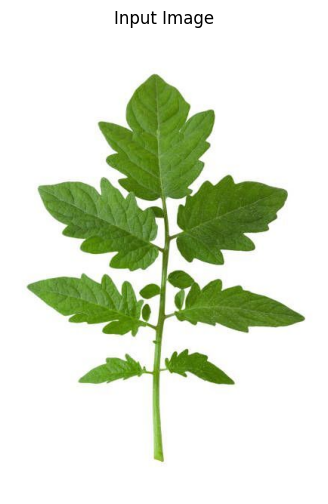

In [50]:
image = Image.open("/content/download (33).jpg").convert("RGB")

print("Original size:", image.size)

plt.figure(figsize=(6, 6))
plt.imshow(image)
plt.title("Input Image")
plt.axis("off")
plt.show()

In [51]:
from google.colab import files

uploaded = files.upload()

print("Uploaded:")
for filename in uploaded.keys():
    print(filename)

Saving download (32).jpg to download (32).jpg
Uploaded:
download (32).jpg


In [52]:
image_path = "/content/download (32).jpg"

predict_plant_disease(image_path)

🌱 PLANT DISEASE PREDICTION
Predicted Class: Pepper,_bell___healthy
Confidence: 97.73%


('Pepper,_bell___healthy', np.float32(97.72849))

In [53]:
predict_top5("/content/download (32).jpg")

🌱 TOP 5 PREDICTIONS
1. Pepper,_bell___healthy → 97.73%
2. Blueberry___healthy → 0.92%
3. Pepper,_bell___Bacterial_spot → 0.66%
4. Cherry_(including_sour)___Powdery_mildew → 0.32%
5. Peach___healthy → 0.12%


[('Pepper,_bell___healthy', 97.7284927368164),
 ('Blueberry___healthy', 0.9229806065559387),
 ('Pepper,_bell___Bacterial_spot', 0.6649945974349976),
 ('Cherry_(including_sour)___Powdery_mildew', 0.31916433572769165),
 ('Peach___healthy', 0.12032989412546158)]

In [54]:
def predict_with_threshold(image_path, threshold=0.70):

    # Load image
    image = Image.open(image_path).convert("RGB")

    # Resize
    image = image.resize((224, 224))

    # Convert to array
    image_array = np.array(image, dtype=np.float32)

    # MobileNetV2 preprocessing
    image_array = tf.keras.applications.mobilenet_v2.preprocess_input(
        image_array
    )

    # Batch dimension
    image_array = np.expand_dims(image_array, axis=0)

    # Prediction
    predictions = final_model.predict(
        image_array,
        verbose=0
    )[0]

    # Best prediction
    predicted_index = np.argmax(predictions)
    confidence = float(predictions[predicted_index])

    print("================================")
    print("🌱 PLANT DISEASE RESULT")
    print("================================")

    if confidence >= threshold:

        predicted_class = class_names[predicted_index]

        print("Status: ✅ Confident Prediction")
        print("Predicted Class:", predicted_class)
        print(f"Confidence: {confidence * 100:.2f}%")

    else:

        predicted_class = "Low confidence"

        print("Status: ⚠️ Low Confidence")
        print("Prediction:", class_names[predicted_index])
        print(f"Confidence: {confidence * 100:.2f}%")
        print("Please upload a clearer leaf image.")

    print("================================")

    return predicted_class, confidence

In [55]:
predict_with_threshold(
    "/content/download (32).jpg",
    threshold=0.70
)

🌱 PLANT DISEASE RESULT
Status: ✅ Confident Prediction
Predicted Class: Pepper,_bell___healthy
Confidence: 97.73%


('Pepper,_bell___healthy', 0.9772849082946777)